In [1]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d nirmalsankalana/plantdoc-dataset
!unzip plantdoc-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/plantdoc-dataset
License(s): CC0-1.0
 96% 856M/896M [00:04<00:00, 123MB/s] 
100% 896M/896M [00:04<00:00, 217MB/s]
Archive:  plantdoc-dataset.zip
  inflating: file_renamer.py         
  inflating: folder_renamer.py       
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_1.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_10.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_2.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_3.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_4.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_5.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_6.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_7.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_8.jpg  
  inflating: test/Apple_Scab_Leaf/test_Apple Scab Leaf_9.jpg  
  inflating: test/Apple_leaf/test_Apple leaf_1.jpg  


In [2]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Preparing metadata (setup.py) ... done


In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from collections import Counter
import numpy as np
import os
import cv2
import tqdm

In [4]:
from segment_anything import sam_model_registry, SamPredictor

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to("cpu")
predictor = SamPredictor(sam)
print("SAM on CPU")

SAM on CPU


## Segmentation by cropping

In [5]:
def segment_leaf_fast(image_rgb):

    predictor.set_image(image_rgb)

    h, w, _ = image_rgb.shape

    input_box = np.array([w*0.1, h*0.1, w*0.9, h*0.9])

    masks, scores, _ = predictor.predict(
        box=input_box,
        multimask_output=False
    )

    mask = masks[0]
    coords = np.column_stack(np.where(mask))

    if len(coords) == 0:
        return image_rgb

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    return image_rgb[y_min:y_max, x_min:x_max]

Selected: train/Squash_Powdery_mildew_leaf/train_Squash Powdery mildew leaf_1.jpg


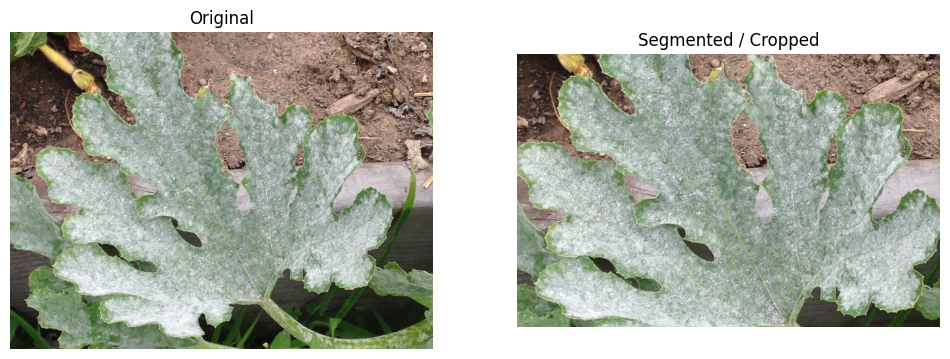

In [ ]:
import random
import os
import cv2
import matplotlib.pyplot as plt

source_root = "train"

class_name = random.choice(os.listdir(source_root))
class_path = os.path.join(source_root, class_name)

img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

print("Selected:", img_path)

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

cropped = segment_leaf_fast(image_rgb)
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cropped)
plt.title("Segmented / Cropped")
plt.axis("off")

plt.show()

In [7]:
selected_classes = [
    "Bell_pepper_leaf",
    "Bell_pepper_leaf_spot",
    "Apple_Scab_Leaf",
    "Apple_leaf",
    "Apple_rust_leaf"
]

source_root = "train"
segmented_root = "PlantDoc_segmented_6"

In [8]:
os.makedirs(segmented_root, exist_ok=True)

for class_name in selected_classes:

    class_path = os.path.join(source_root, class_name)
    save_class_path = os.path.join(segmented_root, class_name)
    os.makedirs(save_class_path, exist_ok=True)

    print(f"Processing {class_name}")

    for img_name in tqdm.tqdm(os.listdir(class_path)):

        img_path = os.path.join(class_path, img_name)
        image = cv2.imread(img_path)
        if image is None:
            continue

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        cropped = segment_leaf_fast(image_rgb)

        save_path = os.path.join(save_class_path, img_name)
        cv2.imwrite(save_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))

Processing Bell_pepper_leaf


100%|██████████| 34/34 [11:54<00:00, 21.02s/it]


In [9]:
import shutil
from google.colab import files

shutil.make_archive('PlantDoc_segmented_6', 'zip', 'PlantDoc_segmented_6')
files.download('PlantDoc_segmented_6.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
!unzip PlantDoc_segmented_6.zip

Archive:  PlantDoc_segmented_6.zip
   creating: PlantDoc_segmented_6/
   creating: PlantDoc_segmented_6/Apple_leaf/
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_1.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_10.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_11.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_12.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_13.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_14.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_15.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_16.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_17.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_18.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_19.jpg  
  inflating: PlantDoc_segmented_6/Apple_leaf/train_Apple leaf_2.jpg  
  inflating: PlantDoc_segmented_6/

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

Training on: cuda


In [27]:
train_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [28]:
segmented_root = "PlantDoc_segmented_6"

full_dataset = datasets.ImageFolder(segmented_root, transform=train_transform)

indices = list(range(len(full_dataset)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_subset = Subset(full_dataset, train_idx)
val_dataset = datasets.ImageFolder(segmented_root, transform=val_transform)
val_subset = Subset(val_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

num_classes = len(full_dataset.classes)
print("Classes:", num_classes)

Classes: 5


In [29]:
targets = full_dataset.targets
class_counts = Counter(targets)

num_samples = len(full_dataset)
class_weights = []

for i in range(num_classes):
    class_weights.append(num_samples / class_counts[i])

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

In [30]:
model = models.efficientnet_b3(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [31]:
def train_model(model, train_loader, val_loader, epochs):

    best_acc = 0

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        model.eval()
        correct = 0
        total = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs,1)

                total += labels.size(0)
                correct += (preds==labels).sum().item()

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = correct / total

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")

        print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f} | Val Acc={val_acc:.4f}")

        scheduler.step()

    print("Best Validation Accuracy:", best_acc)
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

train_model(model, train_loader, val_loader, epochs=3)

Epoch 1: Loss=1.6184 | Val Acc=0.3243
Epoch 2: Loss=1.5938 | Val Acc=0.3243
Epoch 3: Loss=1.5548 | Val Acc=0.4324
Best Validation Accuracy: 0.43243243243243246
Confusion Matrix:
[[ 4  2 13  0  4]
 [ 0 10  0  0  2]
 [ 1  2 10  1  3]
 [ 1  1  1  0  1]
 [ 3  0  6  1  8]]


In [33]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=8e-6)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

train_model(model, train_loader, val_loader, epochs=30)

Epoch 1: Loss=1.5211 | Val Acc=0.4189
Epoch 2: Loss=1.5317 | Val Acc=0.4459
Epoch 3: Loss=1.5090 | Val Acc=0.5000
Epoch 4: Loss=1.4978 | Val Acc=0.4730
Epoch 5: Loss=1.5041 | Val Acc=0.4459
Epoch 6: Loss=1.4897 | Val Acc=0.5000
Epoch 7: Loss=1.4709 | Val Acc=0.5270
Epoch 8: Loss=1.4599 | Val Acc=0.5405
Epoch 9: Loss=1.4414 | Val Acc=0.5135
Epoch 10: Loss=1.4369 | Val Acc=0.5541
Epoch 11: Loss=1.4152 | Val Acc=0.5946
Epoch 12: Loss=1.4212 | Val Acc=0.5676
Epoch 13: Loss=1.4150 | Val Acc=0.5676
Epoch 14: Loss=1.4117 | Val Acc=0.5946
Epoch 15: Loss=1.3951 | Val Acc=0.5811
Epoch 16: Loss=1.3665 | Val Acc=0.5811
Epoch 17: Loss=1.3793 | Val Acc=0.6486
Epoch 18: Loss=1.3829 | Val Acc=0.6216
Epoch 19: Loss=1.3671 | Val Acc=0.6216
Epoch 20: Loss=1.3446 | Val Acc=0.6216
Epoch 21: Loss=1.3638 | Val Acc=0.5946
Epoch 22: Loss=1.3475 | Val Acc=0.6081
Epoch 23: Loss=1.3332 | Val Acc=0.5811
Epoch 24: Loss=1.3329 | Val Acc=0.6081
Epoch 25: Loss=1.3183 | Val Acc=0.6081
Epoch 26: Loss=1.3289 | Val Acc=0.